# Example 05d: Reuse a calculated linearisation

Building the finite-difference plasma-response Jacobians is a substantial part of
initialising the evolutive solver. This example shows how to take the Jacobians
from one solver and supply them to a new solver without rebuilding them.

## Supported contract

Supplying `dIydI` is supported **only** with timescale-based passive-mode
selection:

```python
mode_selection="timescale"
```

The source and destination solvers must use the same:

- machine description and equilibrium grid;
- plasma-profile class and parameter ordering;
- `fix_n_vessel_modes`, or the same `max_mode_frequency` when the number is not fixed;
- plasma-current normalization.

This restriction matters because the columns of

$$
\frac{\partial I_y}{\partial I}
$$

are ordered as active-coil currents, retained passive normal-mode currents, and
total plasma current. Coupling-based selection depends on the equilibrium and
therefore does not provide a sufficiently stable bare-matrix basis for reuse.
Timescale selection is determined by the machine circuit matrices instead.

The example deliberately uses a fixed number of passive modes, which is the
clearest reproducible form of timescale truncation.

## Build a self-contained initial equilibrium

Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.


Magnetic probes --> none provided.


Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


Forward static solve SUCCESS. Tolerance 4.53e-09 (vs. requested 1.00e-08) reached in 24/100 iterations.


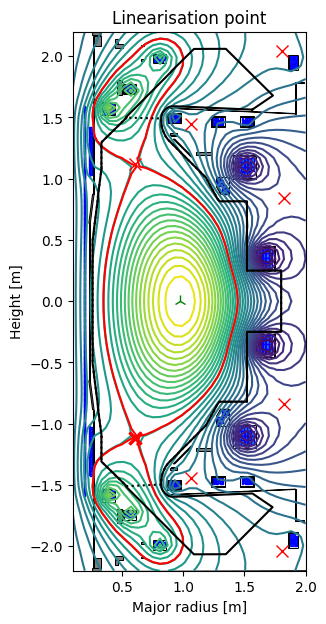

In [1]:
from pathlib import Path
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from freegsnke import build_machine, equilibrium_update, GSstaticsolver, nonlinear_solve
from freegsnke.jtor_update import ConstrainPaxisIp

machine_dir = Path("../machine_configs/MAST-U")
tokamak = build_machine.tokamak(
    active_coils_path=machine_dir / "MAST-U_like_active_coils.pickle",
    passive_coils_path=machine_dir / "MAST-U_like_passive_coils.pickle",
    limiter_path=machine_dir / "MAST-U_like_limiter.pickle",
    wall_path=machine_dir / "MAST-U_like_wall.pickle",
)

eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.1,
    Rmax=2.0,
    Zmin=-2.2,
    Zmax=2.2,
    nx=33,
    ny=65,
)

profiles = ConstrainPaxisIp(
    eq=eq,
    paxis=8.1e3,
    Ip=6.2e5,
    fvac=0.5,
    alpha_m=1.8,
    alpha_n=1.2,
)

with Path("data/simple_diverted_currents_PaxisIp.pk").open("rb") as handle:
    initial_currents = pickle.load(handle)

for coil_name, current in initial_currents.items():
    eq.tokamak.set_coil_current(coil_name, current)

static_solver = GSstaticsolver.NKGSsolver(eq)
static_solver.solve(
    eq,
    profiles,
    target_relative_tolerance=1e-8,
    verbose=False,
)

fig, ax = plt.subplots(figsize=(4, 7))
eq.plot(axis=ax, show=False)
eq.tokamak.plot(axis=ax, show=False)
ax.set_xlim(0.1, 2.0)
ax.set_ylim(-2.2, 2.2)
ax.set_title("Linearisation point")
plt.show()

## 1. Build the source linearisation

Here the 12 longest-timescale passive modes are retained. Fixing the number makes
the current basis independent of the equilibrium and avoids ambiguity at a
frequency cutoff. `mode_removal` need not be set: it is automatically disabled
for timescale selection.

`n_linearization_workers` controls only the independent finite-difference solves.
Keep it at 1 for serial construction, or raise it to an appropriate value for the
machine on which the notebook runs.

In [2]:
N_PASSIVE_MODES = 12
MAX_MODE_FREQUENCY = 10**2.5

common_solver_options = dict(
    eq=eq,
    profiles=profiles,
    GSStaticSolver=static_solver,
    full_timestep=5e-4,
    plasma_resistivity=1e-6,
    plasma_norm_factor=1e3,
    mode_selection="timescale",
    fix_n_vessel_modes=N_PASSIVE_MODES,
    max_mode_frequency=MAX_MODE_FREQUENCY,
)

n_workers = int(os.environ.get("FREEGSNKE_EXAMPLE_WORKERS", "1"))
source_solver = nonlinear_solve.nl_solver(
    **common_solver_options,
    n_linearization_workers=n_workers,
)

print("dIydI shape:", source_solver.dIydI_ICs.shape)
print("dIydtheta shape:", source_solver.dIydtheta_ICs.shape)

-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 4.53e-09 (vs. requested 1.00e-08) reached in 0/100 iterations.
-----
Instantiating nonlinear solver objects...
done.
-----
Identifying mode selection criteria...


      'mode_selection=timescale' selected: retaining the 12 lowest-frequency passive modes.
      Plasma-coupling metrics are not used for mode selection or subsequent mode removal.
-----
Initial mode selection:
   Active coils
      total selected = 12 (out of 12)
   Passive structures
      12 lowest-frequency (longest-timescale) modes selected
-----
Building the 755 x 25 Jacobian (dIy/dI) of plasma current density (inside the LCFS) with respect to all metal currents and the total plasma current.


Building the 755 x 3 Jacobian (dIy/dtheta) of plasma current density (inside the LCFS) with respect to all plasma current density profile parameters within Jtor.


Built the 1 x 25 Jacobian (ds/dI) of plasma descriptors with respect to all metal currents and the total plasma current.
Built the 1 x 3 Jacobian (ds/dtheta) of plasma descriptors with respect to all plasma current density profile parameters within Jtor.
-----
Stability paramters:


   Deformable plasma metrics:
      Growth rate = [135.58105681] [1/s]
      Instability timescale = [0.00737566] [s]
      Inductive stability margin = [0.15781317+0.j]
   Rigid plasma metrics:
      Leuer parameter (ratio of stabilsing to de-stabilising force gradients):
          between all metals and all metals = 1.7773523563115612
          between all metals and active metals = 1.7773523563115612
          between passive metals and active metals = 1.7773376460602843
-----
Evolutive solver timestep:
      Solver timestep 'dt_step' has been set to 0.0005 as requested.
      Ensure it is smaller than the growth rate else you may find numerical instability in any subsequent evoltuive simulations!
-----
dIydI shape: (755, 25)
dIydtheta shape: (755, 3)


## 2. Stash what the new solver needs

Copy the two arrays from the source solver. The copies are important if the source
solver will continue to evolve or relinearise.

The metadata next to the arrays is not consumed automatically; it records the
contract that must be repeated when constructing the destination solver. A caller
that persists this cache can use `numpy.savez_compressed`, pickle, or its own data
format, but should persist these settings alongside the matrices.

In [3]:
linearisation_cache = {
    "dIydI": source_solver.dIydI_ICs.copy(),
    "dIydtheta": source_solver.dIydtheta_ICs.copy(),
    "mode_selection": "timescale",
    "fix_n_vessel_modes": N_PASSIVE_MODES,
    "max_mode_frequency": MAX_MODE_FREQUENCY,
    "plasma_norm_factor": source_solver.plasma_norm_factor,
}

# Example persistence, if required:
# np.savez_compressed("my_linearisation.npz", **linearisation_cache)
# saved = np.load("my_linearisation.npz")

print("Cached current columns:", linearisation_cache["dIydI"].shape[1])

Cached current columns: 25


## 3. Instantiate a new solver using the cache

Supplying both matrices skips their finite-difference GS calculations. The normal
modes and inexpensive no-GS response estimate are still constructed so that the
new solver has the complete circuit state and perturbation bookkeeping it needs.

The constructor checks the matrix dimensions after selecting the passive-mode
basis. It cannot infer all source metadata from a bare NumPy array, so repeating
the settings above remains the caller's responsibility.

In [4]:
reused_solver = nonlinear_solve.nl_solver(
    **common_solver_options,
    dIydI=linearisation_cache["dIydI"],
    dIydtheta=linearisation_cache["dIydtheta"],
)

np.testing.assert_array_equal(
    reused_solver.dIydI_ICs,
    linearisation_cache["dIydI"],
)
np.testing.assert_array_equal(
    reused_solver.dIydtheta_ICs,
    linearisation_cache["dIydtheta"],
)
print("The cached linearisation was reused unchanged.")

-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 4.53e-09 (vs. requested 1.00e-08) reached in 0/100 iterations.
-----
Instantiating nonlinear solver objects...
done.
-----
Identifying mode selection criteria...


      'mode_selection=timescale' selected: retaining the 12 lowest-frequency passive modes.
      Plasma-coupling metrics are not used for mode selection or subsequent mode removal.
-----
Initial mode selection:
   Active coils
      total selected = 12 (out of 12)
   Passive structures
      12 lowest-frequency (longest-timescale) modes selected
-----
-----
Stability paramters:


   Deformable plasma metrics:
      Growth rate = [135.58105681] [1/s]
      Instability timescale = [0.00737566] [s]
      Inductive stability margin = [0.15781317+0.j]
   Rigid plasma metrics:
      Leuer parameter (ratio of stabilsing to de-stabilising force gradients):
          between all metals and all metals = 1.7773523563115612
          between all metals and active metals = 1.7773523563115612
          between passive metals and active metals = 1.7773376460602843
-----
Evolutive solver timestep:
      Solver timestep 'dt_step' has been set to 0.0005 as requested.
      Ensure it is smaller than the growth rate else you may find numerical instability in any subsequent evoltuive simulations!
-----
The cached linearisation was reused unchanged.


## 4. Check a GS-backed linear evolution step

The reused matrix is sufficient for `linear_only=True, no_GS=False`: the circuit
and plasma response are advanced with the cached linear model, then the GS equation
is solved for the updated equilibrium. Descriptor Jacobians such as `dvdId` are not
needed on this route; they are specific to evolution with `no_GS=True`.

Starting the source and destination solvers from the same state and applying the
same voltage must therefore produce the same update.

In [5]:
source_solver.initialize_from_ICs(eq, profiles)
reused_solver.initialize_from_ICs(
    eq,
    profiles,
    dIydI=linearisation_cache["dIydI"],
    dIydtheta=linearisation_cache["dIydtheta"],
)

active_voltages = (
    source_solver.vessel_currents_vec * source_solver.evol_metal_curr.coil_resist
)[: source_solver.n_active_coils]

for solver in (source_solver, reused_solver):
    solver.nlstepper(
        active_voltage_vec=active_voltages,
        linear_only=True,
        no_GS=False,
        verbose=False,
    )

np.testing.assert_allclose(
    reused_solver.currents_vec,
    source_solver.currents_vec,
    rtol=1e-12,
    atol=1e-12,
)
np.testing.assert_allclose(
    reused_solver.profiles1.jtor,
    source_solver.profiles1.jtor,
    rtol=1e-10,
    atol=1e-10,
)
print("GS-backed linear step agrees with the source solver.")

GS-backed linear step agrees with the source solver.


## Unsupported uses

### Do not combine a supplied `dIydI` with coupling-based mode selection

Setting `mode_removal=False` does **not** make this safe. Coupling-based initial
selection is itself equilibrium dependent, so FreeGSNKE rejects the combination
before doing expensive setup.

In [6]:
try:
    nonlinear_solve.nl_solver(
        **{
            **common_solver_options,
            "mode_selection": "coupling",
            "mode_removal": False,
        },
        dIydI=linearisation_cache["dIydI"],
        dIydtheta=linearisation_cache["dIydtheta"],
    )
except ValueError as error:
    print("Expected error:", error)

-----
Expected error: Supplying 'dIydI' is supported only with 'mode_selection="timescale"'. Coupling-based selection depends on the initial equilibrium and may change the current-mode basis. Omit 'dIydI' to rebuild the linearisation, or use timescale selection with the same settings as the source solver.


### Do not change the timescale mode basis

The matrix columns refer to the retained modes in the source solver. Selecting a
different number of passive modes therefore gives a dimension mismatch and is
rejected with an explanation rather than failing later inside the linear solver.

In [7]:
try:
    nonlinear_solve.nl_solver(
        **{
            **common_solver_options,
            "fix_n_vessel_modes": N_PASSIVE_MODES - 1,
        },
        dIydI=linearisation_cache["dIydI"],
        dIydtheta=linearisation_cache["dIydtheta"],
    )
except ValueError as error:
    print("Expected error:", error)

-----
Checking that the provided 'eq' and 'profiles' are a GS solution...
Forward static solve SUCCESS. Tolerance 4.53e-09 (vs. requested 1.00e-08) reached in 0/100 iterations.
-----
Instantiating nonlinear solver objects...


done.
-----
Identifying mode selection criteria...


      'mode_selection=timescale' selected: retaining the 11 lowest-frequency passive modes.
      Plasma-coupling metrics are not used for mode selection or subsequent mode removal.
-----
Initial mode selection:
   Active coils
      total selected = 12 (out of 12)
   Passive structures
      11 lowest-frequency (longest-timescale) modes selected
-----
Expected error: Supplied 'dIydI' has shape (755, 25), but (755, 24) is required by the selected timescale mode basis; reuse the same machine, grid, and timescale-selection settings as the source solver.


## Summary

For supported reuse:

1. Copy `source_solver.dIydI_ICs` and `source_solver.dIydtheta_ICs`.
2. Record the machine, grid, profile parameterisation, normalization, and
   timescale-selection settings used to build them.
3. Instantiate the destination solver with `mode_selection="timescale"` and the
   same settings.
4. Pass both copied arrays to the constructor.

If the mode basis or equilibrium setup cannot be guaranteed compatible, omit the
cached `dIydI` and let the new solver calculate a fresh linearisation.